In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
import plotly.express as px
from scipy.stats.mstats import trimmed_var
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("/content/SCFP2019.csv")
df.head()

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,6119.779308,2,75,6,12,4,2,0,...,5,3,6,3,2,10,6,6,3,3
1,1,12,4712.374912,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
2,1,13,5145.224455,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
3,1,14,5297.663412,2,75,6,12,4,2,0,...,5,2,6,2,1,10,4,4,2,2
4,1,15,4761.812371,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2


**Summary:**
This file appears to be the **2019 Survey of Consumer Finances (SCF) Panel dataset**, which is a large micro-level dataset about household financial conditions. 📊

**What it contains (based on structure + column names):**

* **Rows:** 28,885 records → likely individual households or survey responses
* **Columns:** 351 variables → demographic + financial + categorical indicators

**Main data themes**

1. **Demographics**

   * Age (`AGE`, `AGECL`)
   * Gender of household head (`HHSEX`)
   * Education (`EDUC`, `EDCL`)
   * Marital status (`MARRIED`)
   * Number of kids (`KIDS`)
   * Race categories (`RACE`, `RACECL`, etc.)

2. **Employment & Social structure**

   * Labor force participation (`LF`)
   * Occupation categories (`OCCAT1`, `OCCAT2`)
   * Industry (`INDCAT`)
   * Family structure (`FAMSTRUCT`)

3. **Income & Spending**

   * Income categories (`INCCAT`, `INCQRTCAT`)
   * Food spending (`FOODHOME`)
   * Net income percentile categories

4. **Wealth / Assets**

   * Asset categories (`ASSETCAT`)
   * Net worth categories (`NWCAT`)
   * Net worth percentiles (`NWPCTLECAT`)

5. **Survey metadata**

   * Survey weights (`WGT`) → used to make results nationally representative
   * ID / panel tracking variables (`YY1`, `Y1`)

---

**Typical use cases**

* Wealth inequality research
* Household finance modeling
* Socioeconomic ML prediction tasks
* Policy and economic analysis

In [ ]:
# Filtering Datasets where TURNFEAR = 1 and saving the resulting dataset into df_fear.
# What TURNFEAR means?
# Typically related to Financial Fragility, Fear of economic downturn.
mask = df["TURNFEAR"]==1
df_fear = df[mask]
print("df_fear shape :",df_fear.shape)
df_fear.head()

df_fear shape : (4623, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


In [ ]:
age_groups = df_fear["AGECL"].unique()
print("Age Groups:",age_groups)

# Checking what are the age categories are in the dataset df_fear

Age Groups: [3 5 1 2 4 6]


In [ ]:
# Now we want to convert the age categroy codes into human-readable labels using a dictionary mapping.

agecl_dict = {
    1: "Under 35",
    2: "35-44",
    3: "45-54",
    4: "55-64",
    5: "65-74",
    6: "75 or Older"
}

age_cl = df_fear["AGECL"].replace(agecl_dict) # Checs each value in AGECl and finds a key for it in agecl_dict and finally replaces it with the corresponding value.
age_cl.head(10)

,AGECL
5,45-54
6,45-54
7,45-54
8,45-54
9,45-54
110,65-74
111,65-74
112,65-74
113,65-74
114,65-74


<Axes: xlabel='AGECL'>

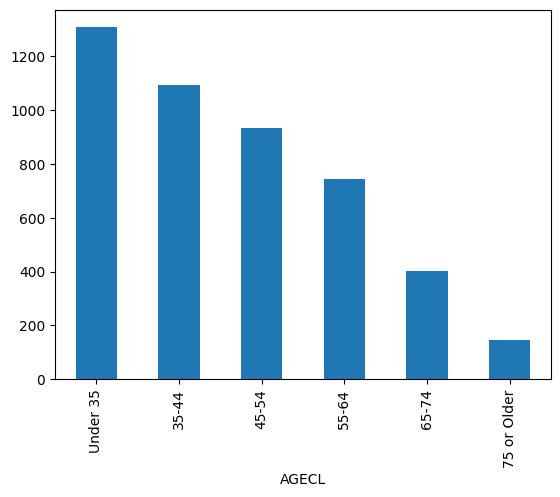

In [ ]:
# counting number of values in every category and plotting a bar graph

age_cl_value_counts = age_cl.value_counts()
age_cl_value_counts.plot(kind='bar')


<Axes: >

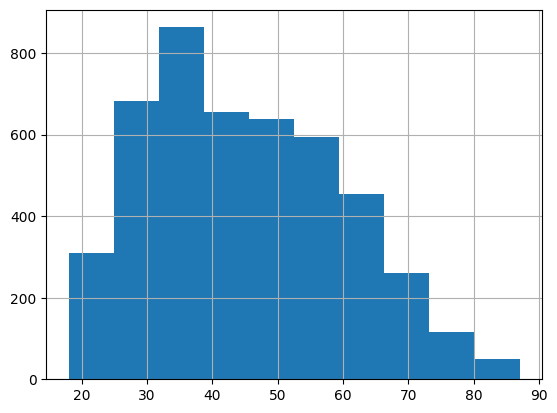

In [ ]:
# Bulids histogram of actual ages by dividing them into 10 bins showing the frequency distribution
# Interpretation - Financial Fear is more in the age group 25 - 50 (working age households)
# Less Fear Among - Very Young(fewer assets/ debts) & Very old(retired/ stabilized finances)
df_fear['AGE'].hist(bins=10)

In [ ]:
# Decoding the income category into income percentile range.

inccat_dict = {
    1: "0-20",
    2: "20-39.9",
    3: "40-59.9",
    4: "60-79.9",
    5: "80-89.9",
    6: "90-100"
}

inccat = df_fear["INCCAT"].replace(inccat_dict)
inccat.head(10)

,INCCAT
5,20-39.9
6,20-39.9
7,20-39.9
8,20-39.9
9,20-39.9
110,0-20
111,0-20
112,0-20
113,0-20
114,0-20


<Axes: xlabel='INCCAT'>

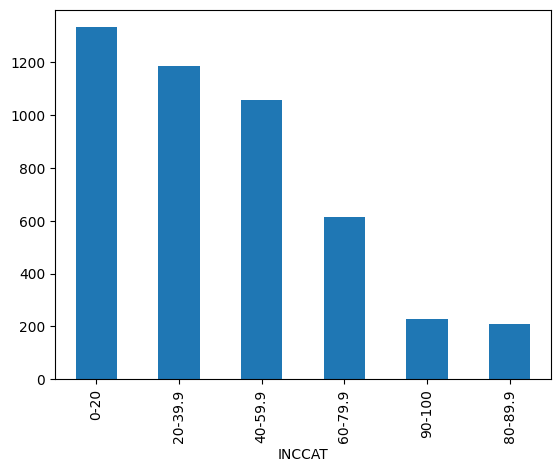

In [ ]:
inccat_val_counts = inccat.value_counts()
inccat_val_counts.plot(kind='bar')


In [ ]:
columns = ["ASSET","HOUSES","INCOME","DEBT","EDUC"]
corr = df[columns].corr()

corr.style.background_gradient(axis=None)


,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.519827,0.622429,0.261250,0.116673
HOUSES,0.519827,1.000000,0.247852,0.266661,0.169300
INCOME,0.622429,0.247852,1.000000,0.114646,0.069400
DEBT,0.261250,0.266661,0.114646,1.000000,0.054179
EDUC,0.116673,0.169300,0.069400,0.054179,1.000000


In [ ]:
corr_fear = df_fear[columns].corr()
corr_fear.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.583288,0.722074,0.474658,0.113536
HOUSES,0.583288,1.000000,0.264099,0.962629,0.160348
INCOME,0.722074,0.264099,1.000000,0.172393,0.133170
DEBT,0.474658,0.962629,0.172393,1.000000,0.177386
EDUC,0.113536,0.160348,0.133170,0.177386,1.000000


<Figure size 1200x600 with 0 Axes>

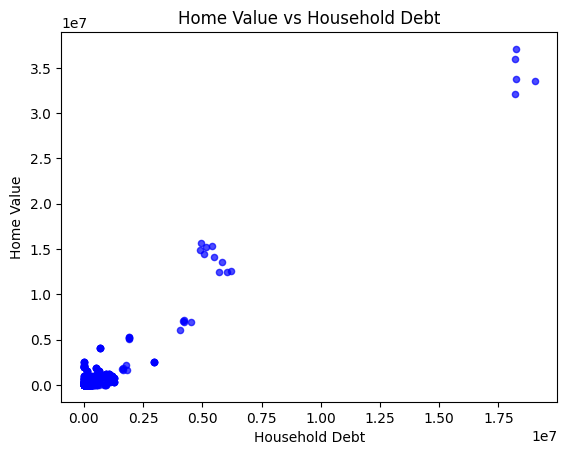

In [ ]:
# Scatter Graph b/w Home Value and Household Debt

plt.figure(figsize=(12, 6) )
df_fear.plot.scatter(x='DEBT', y="HOUSES", c='blue', alpha=0.7, marker='o')
plt.xlabel('Household Debt')
plt.ylabel('Home Value')
plt.title('Home Value vs Household Debt')
plt.show()


**There are tons of other useful ways to understand this dataset better. Kindly explore them on your own.**

In [ ]:
df["TURNFEAR"].value_counts()

,count
TURNFEAR,
0,24262
1,4623


In [ ]:
features = ["AGE", "INCCAT", "NWCAT", "ASSETCAT"] # Choosing only a limited feature rn.
X = df[features]
X = X.dropna()

In [ ]:
# Scaling beacuse without scaling AGE was dominating Clustering.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **K-Means Clustering**

is an unsupervised learning algorithm used to divide data into K distinct groups(clusters) based on similarity.

Unlike Classification, it has no labels and no target variable but the primary motive is to discover hidden structure in data.

K-Means tries to group data points so that:

Points inside a cluster are similar and Clusters are differnet from each other.

The similarity is measured using **Euclidean distance**.

## How K-Means Works

Step 1 - Choose K which is the number of clusters.

Step 2 - Initialize K centroids(center of cluster) randomly.

Step 3 - Each data point goes to the nearest centroid.

Step 4 - Update the Centroids. New Centroid = mean of assigned points.

Step 5 - Repeat until the centroids stop moving amd convergence is achieved.

*Convergence* - the point during training when an optimization algo has reached a stable state and futher training does not significantly reduce the loss or implrove model performance.

*The Mathematical Objective* - Minimizing Inerita which can be explained as the sum of the (squared) distances of data ponts to their nearest cluster centroid, indicating how internally compact the clusters are. So more inertia means, less tight clusters and less inertia means more tight clusters.

**Strengths of K-Means**

✔ Fast

✔ Easy to understand

✔ Works well on numeric data

✔ Good baseline clustering method

**Limitations of K-Means**

1. Must choose K which means there is no automatic detection.

2. K-Means is very sensitive to outliers.

3. Requires numeric features, so if there are categorical features, we need to encode them first.

Remember that clusters can only **represent** statistically similar groups but their **interpretation** is a human task.

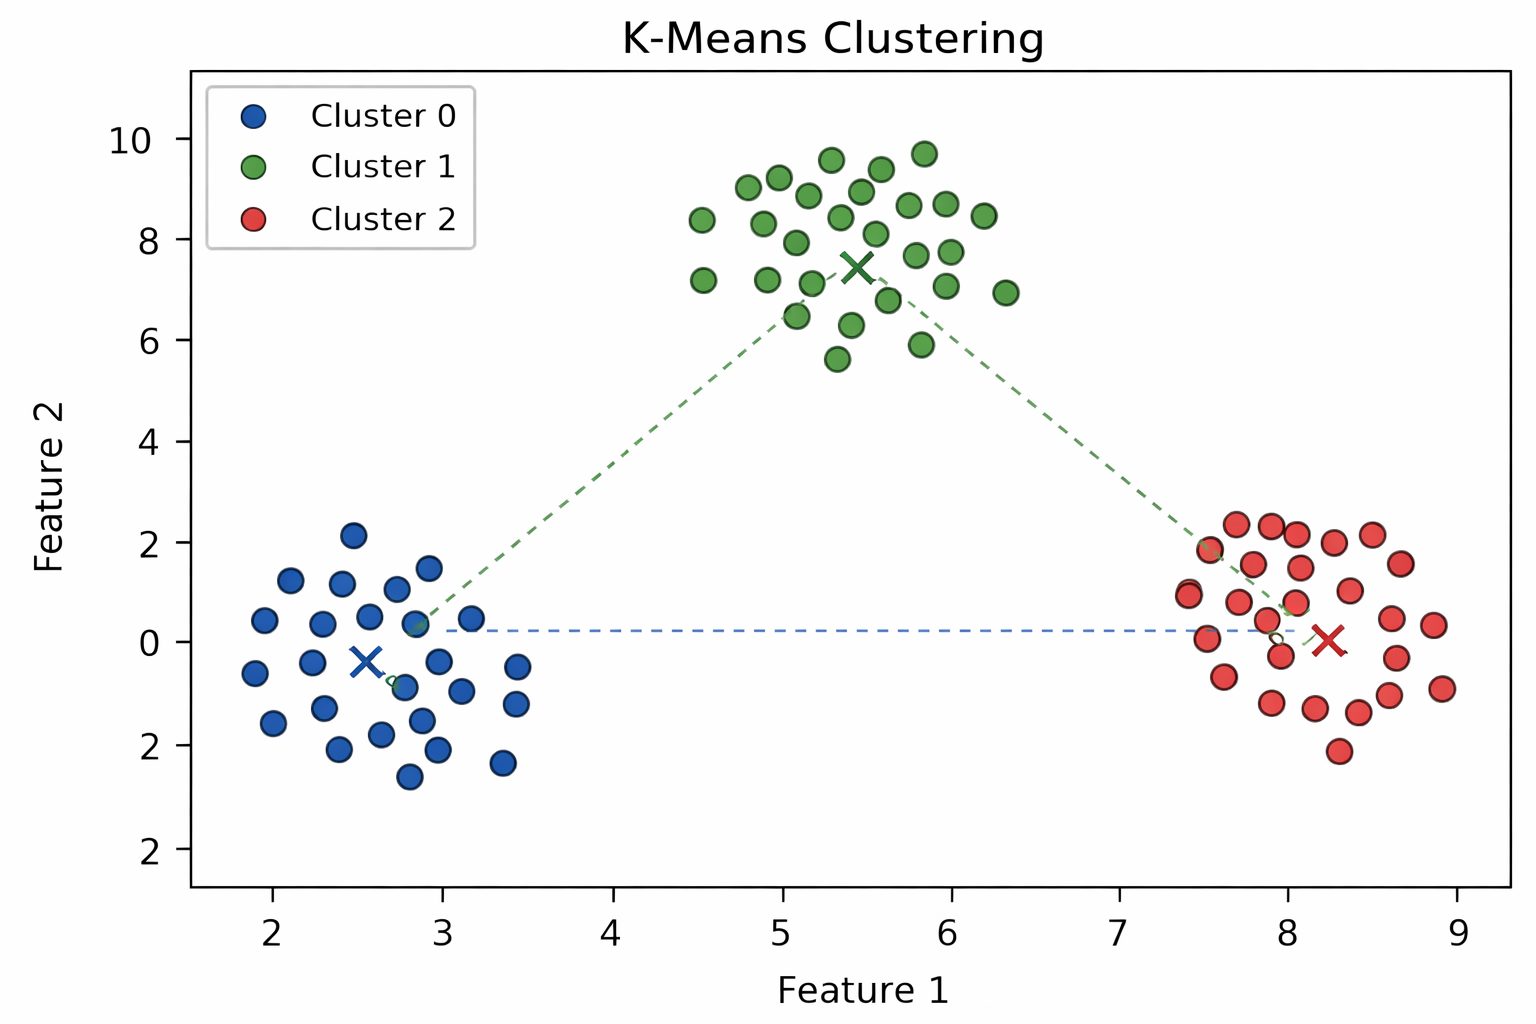

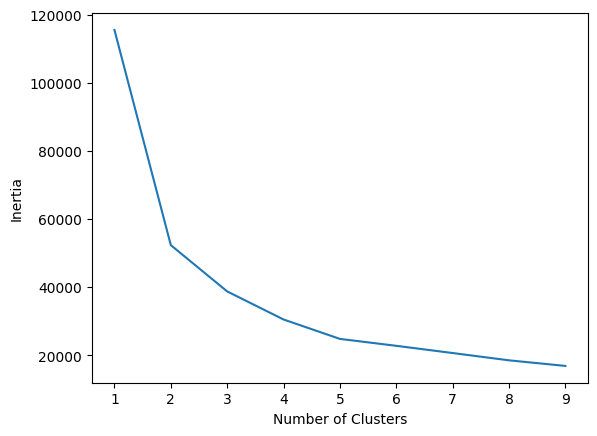

In [ ]:
# Using K-Means Clustering for Model training and choosing the optimal K.
# This method is known as "The Elbow Method"
# Tip - Look for the elbow bend in the graph.
inertia = []

for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In The Curve:

K = 1 to 2 and 2 to 3 , the drop is very large.

K = 3 to 4 Moderate drop

K = 4 and above is small gradual decrease

So, logically K = 3 is the most defensible choice.

Why not K = 4? 🤔

You could argue for 4 if:

Domain interpretation improves

Clusters become more meaningful

But visually:

👉 Improvement from 3 → 4 is noticeably smaller

So 3 is cleaner statistically.

In [ ]:
# Traing the final model now.

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_
X["Cluster"] = clusters
X.groupby("Cluster").mean() # interpreting Clusters to analyze mean AGE per cluster, income distribution, fear concentration.

,AGE,INCCAT,NWCAT,ASSETCAT
Cluster,,,,
0,59.049449,5.367666,4.606200,5.567000
1,36.359261,2.621108,1.642111,1.996412
2,65.100766,2.319829,2.509934,2.832489


In [ ]:
labels = model.labels_
labels[:10]

array([2, 2, 2, 2, 2, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
# Plotting "HOUSES" vs "DEBT" with hue = label
# Each dot in this scatter plot says "For this household, how much debt vs how much housing wealth?”
sns.scatterplot(
    x = df["DEBT"] / 1e6,
    y = df["HOUSES"] / 1e6,
    hue = labels,
    palette = "deep"
)

plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Home Value vs Household Debt")

plt.show()

ValueError: array length 28885 does not match index length 4623

DIY task - Silhouette Score